# Pleasant Weather Outlook (PWO) 

Group #8's project is on a Pleasant Weather Outlook using temperature, wind speed, sky cover, and dew point. 

## Distribution and Acronyms
Temperature (TMP)  ~ 35% 

Wind Speed (WIND) ~ 20% 

Sky Cover (TCDC) ~ 20% 

Dew Point (DPT) ~ 25% 

# Scale and Parameters

Scale = 1 to 5

1 is the worst possible conditions, showing 80-100% cloud cover, temperatures either above 100°F or below 30°F, wind speed greater than 25 mph, and a dewpoint above 75°F 

5 is the best possible conditions, showing 0-20% cloud cover, temperatures in between 60°F and 75°F, wind speed less than 5 mph, and a dewpoint below 60°F 

In [7]:
# Import Statements 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask

# Imported NAM Data 
run = pd.Timestamp("2024-10-09-00")
H = Herbie(run, model="nam", product="conusnest.hiresf", fxx=6, save_dir='./data/', overwrite=True)
H.inventory('TCDC')

# 
ss2 = '((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))'
ss2 = H.xarray(ss2)
ss2[1]['wsp'] = np.sqrt(ss2[1]['u10']**2+ss2[1]['v10']**2) 
ss2[1]['tcc'] = ss2[0]['tcc']
ss2[1]['t2m'] = ss2[2]['t2m']
ss2[1]['d2m'] = ss2[2]['d2m']
ds = ss2[1]
ds = ds.drop_vars('u10')
ds = ds.drop_vars('v10')
ds

✅ Found ┊ model=nam ┊ product=conusnest.hiresf ┊ 2024-Oct-09 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:1280: UserWarning: Will not remove GRIB file because it previously existed.
  warnings.warn("Will not remove GRIB file because it previously existed.")
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat 

Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.


<xarray.Dataset> Size: 61MB
Dimensions:                (y: 1059, x: 1799)
Coordinates:
    time                   datetime64[ns] 8B 2024-10-09
    step                   timedelta64[ns] 8B 06:00:00
    heightAboveGround      float64 8B 10.0
    latitude               (y, x) float64 15MB 21.14 21.14 21.15 ... 47.85 47.84
    longitude              (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time             datetime64[ns] 8B 2024-10-09T06:00:00
    gribfile_projection    object 8B None
    atmosphereSingleLayer  float64 8B 0.0
Dimensions without coordinates: y, x
Data variables:
    wsp                    (y, x) float32 8MB 6.13 6.147 6.144 ... 15.45 15.61
    tcc                    (y, x) float32 8MB ...
    t2m                    (y, x) float32 8MB ...
    d2m                    (y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   nam
    product:                 conusnest.hiresf
    description:             North America Mesoscale - CONUS
    remote_grib:             https://noaa-nam-pds.s3.amazonaws.com/nam.202410...
    local_grib:              data/nam/20241009/subset_e9b2c12d__nam.t00z.conu...
    search:                  ((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))

In [8]:
# Save data as a NetCDF File 
filename = 'nam_whole_run.nc'
ds.to_netcdf(filename)

sh: 1: getfattr: not found


PermissionError: [Errno 13] Permission denied: '/courses/meteo473/sp26/473_sp26_group8/nam_whole_run.nc'

In [ ]:
ds_check = xr.open_dataset("nam_whole_run.nc")
print(ds_check)

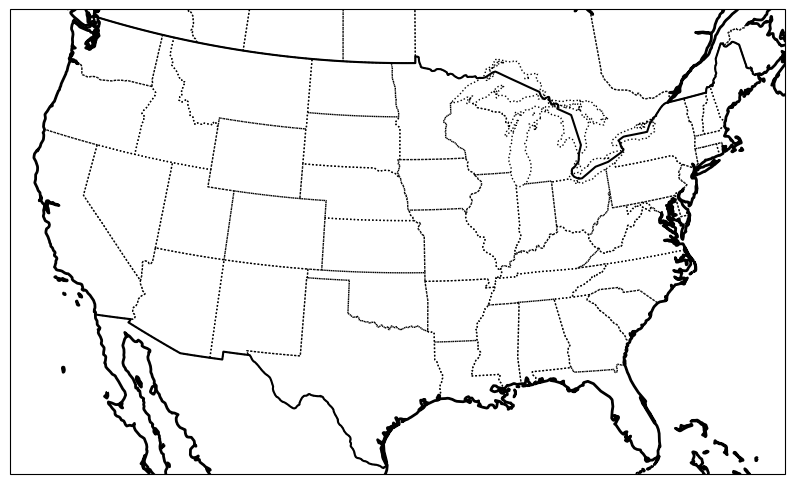

In [9]:
def GeoAxes():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())
    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.5)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':',linewidth=1)
    ax.set_extent([-120, -73, 23, 50])
    return fig,ax
fig,ax=GeoAxes()